In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import csv
%matplotlib inline

In [6]:
df=pd.read_csv('C:\\Users\\lappixel\\Documents\\GitHub\\tehran-house-price-prediction\\data\\HousePrice.csv')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [8]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


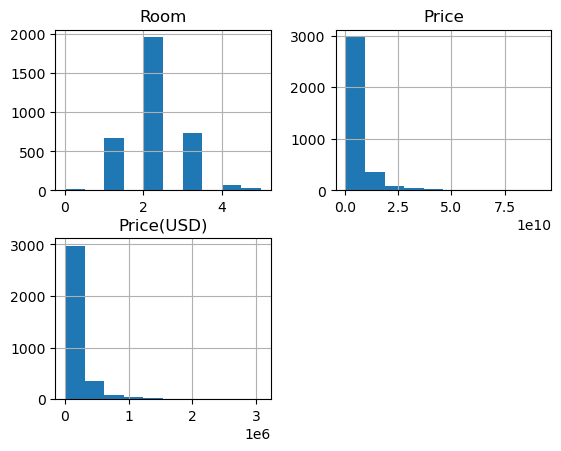

In [10]:
viz = df[['Room','Price','Parking' ,'Warehouse', 'Elevator','Price(USD)']]
viz.hist()
plt.show()

In [11]:
cdf = df[['Room','Price']]
cdf.head(9)

,Room,Price
0,1,1.850000e+09
1,1,1.850000e+09
2,2,5.500000e+08
3,2,9.025000e+08
4,2,7.000000e+09
5,2,2.050000e+09
6,2,6.000000e+08
7,1,2.150000e+09
8,2,4.930000e+08


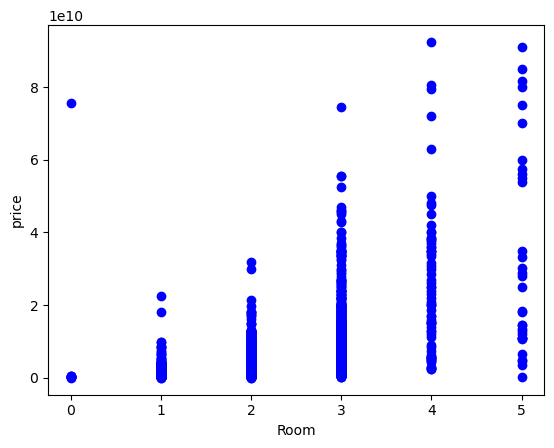

In [14]:
plt.scatter(cdf.Room , cdf.Price,  color='blue')
plt.xlabel("Room")
plt.ylabel("price")
plt.show()

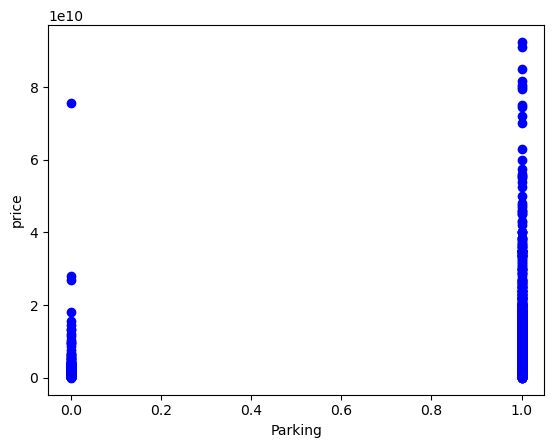

In [16]:
plt.scatter(df.Parking , df.Price,  color='blue')
plt.xlabel("Parking")
plt.ylabel("price")
plt.show()

In [24]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]


In [28]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x = np.asanyarray(train[['Room']])
y = np.asanyarray(train[['Price']])
regr.fit (x, y)
print ('Coefficients: ', regr.coef_)
print ('intercept: ', regr.intercept_)

Coefficients:  [[5.80109109e+09]]
intercept:  [-6.78782645e+09]


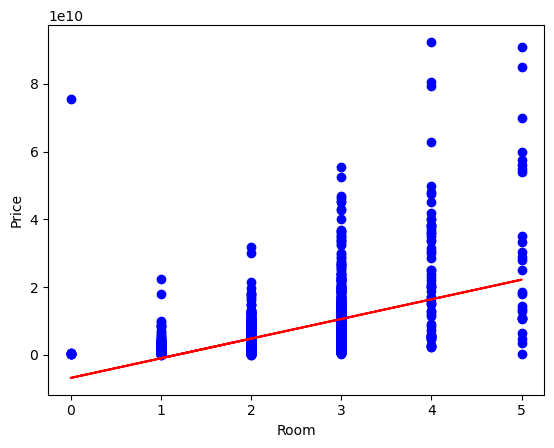

In [31]:
plt.scatter(train.Room, train.Price,  color='blue')
plt.plot(x, regr.coef_[0][0]*x + regr.intercept_[0], '-r')
plt.xlabel("Room")
plt.ylabel("Price")
plt.show()

In [33]:
y_hat= regr.predict(test[['Room']])
x = np.asanyarray(test[['Room']])
y = np.asanyarray(test[['Price']])
print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y) ** 2))
print('Variance score: %.2f' % regr.score(x, y))

Residual sum of squares: 54172050887724130304.00
Variance score: 0.34


C:\Users\lappixel\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [84]:
regr.predict([[3]])

array([[1.06154468e+10]])

In [86]:
regr.predict([[2]])

array([[4.81435573e+09]])